# Normalized Difference Built-up Index (NDBI) — Mapping Urban Surfaces in Gauteng

### What is NDBI?

The **Normalized Difference Built-up Index (NDBI)** is a spectral index derived from satellite imagery that is designed to highlight **impervious urban surfaces** such as rooftops, roads, parking lots, and concrete structures. It was first proposed by Zha, Gao & Ni (2003) and has since become one of the most widely used indices in urban remote sensing.

The formula is pretty straightforward:

$$NDBI = \frac{SWIR1 - NIR}{SWIR1 + NIR} = \frac{B6 - B5}{B6 + B5}$$

The logic behind it is grounded in the **physical properties of surface materials**:

- **Built-up surfaces** (concrete, asphalt, metal roofing) reflect strongly in the 
  shortwave infrared (SWIR) and weakly in the near-infrared (NIR), producing 
  **positive NDBI values**
- **Vegetation** does the opposite — it absorbs SWIR and reflects NIR strongly 
  (this is the same mechanism NDVI exploits), producing **negative NDBI values**
- **Water** absorbs strongly across both bands, also producing negative values but 
  typically more extreme than vegetation
- **Bare soil** sits near zero, making it spectrally ambiguous and the main 
  source of confusion in classification

NDBI values range from **−1 to +1**, where values greater than 0 are generally 
interpreted as built-up or impervious surfaces.

## Why Gauteng?

Well for starters its because I already have the Landsat data for it, so why not? But secondly, I think Gauteng is one of the most compelling case studies for urban remote sensing on the African continent becuase of its density and complexity. Gaueng is the smallest province in South Africa but also the most populated, with well over 16 million people living it. The province has also has ongoing urban exansion, with development in highways, industrial zones, and railways.

## What to look for in the map

This is my first time doing a NDBI analysis so I will mainly be looking for:

- The **Johannesburg–Pretoria urban corridor** running roughly north–south through 
  the centre of the scene — this should appear as the most strongly positive NDBI zone
- **Ekurhuleni** (East Rand) to the east, one of Africa's largest industrial 
  concentrations
- **Mine dumps** west and southwest of Johannesburg — watch how their NDBI signal 
  compares to genuine built-up areas
- The **greener suburban zones** of northern Johannesburg (Sandton, Fourways, 
  Midrand) where tree canopy suppresses NDBI despite high levels of urbanisation — 
  a known limitation of the index
- **Agricultural and grassland areas** on the urban fringe showing negative NDBI values

There are some said limitations to NDBI but I will see them when I cross that bridge.

### Data Used

Landsat 9 data can be accessed from USGS EarthExplorer. You can download data from here: https://earthexplorer.usgs.gov

### Options and libraries

In [1]:
options(
  repr.plot.width  = 12,
  repr.plot.height = 7,
  repr.plot.res    = 200
)

In [3]:
library(tidyverse)
library(terra)
library(sf)
library(scales)

### Load Landsat 9 bands B1–B7

We build the file paths programmatically so adding/removing bands later only requires changing the band numbers vector, nothing else.

Landsat 9 Collection 2 Level-2 band mapping:
- B1 — Coastal aerosol   (0.43–0.45 µm)
- B2 — Blue              (0.45–0.51 µm)
- B3 — Green             (0.53–0.59 µm)
- B4 — Red               (0.64–0.67 µm)
- B5 — Near Infrared     (0.85–0.88 µm)
- B6 — SWIR-1            (1.57–1.65 µm)
- B7 — SWIR-2            (2.11–2.29 µm)

In [4]:
LandsatDir  <- "Data/Gauteng_Landsat"
LandsatBase <- "LC09_L2SP_170078_20260210_20260211_02_T1_SR_B"

BandPaths <- paste0(LandsatDir, "/", LandsatBase, 1:7, ".TIF")

In [5]:
# Short names for data wrangling
BandNamesShort <- c("B1_Coastal", "B2_Blue",  "B3_Green",
                    "B4_Red",     "B5_NIR",   "B6_SWIR1", "B7_SWIR2")

Wavelengths <- c(0.443, 0.482, 0.561, 0.655, 0.865, 1.609, 2.201)

### Apply Landsat Collection 2 scale factor

Usually Level-2 Surface Reflectance products store values as scaled integers. The official USGS scale factor is 0.0000275 with an offset of -0.2. After applying this, values should fall between 0 and 1 (occasionally slightly above 1 for bright surfaces — this is normal).

Values $<=$ 0 after scaling are either fill/cloud pixels and we have to mask them out.

In [6]:
LandsatStack <- rast(BandPaths) * 0.0000275 - 0.2

In [7]:
# Mask out invalid pixels (fill value in raw data is 0; after scaling → -0.2)
LandsatStack[LandsatStack < 0] <- NA

In [8]:
names(LandsatStack) <- BandNamesShort

In [9]:
print(LandsatStack)

class       : SpatRaster 
size        : 7821, 7751, 7  (nrow, ncol, nlyr)
resolution  : 30, 30  (x, y)
extent      : 533085, 765615, -2993415, -2758785  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 35N (EPSG:32635) 
source      : spat_19804eeb4fce_6528_CjcR62DykkoqBId.tif 
names       :   B1_Coastal,      B2_Blue,     B3_Green,       B4_Red,       B5_NIR,     B6_SWIR1, ... 
min values  : 7.498264e-06, 7.498264e-06, 7.498264e-06, 7.498264e-06, 7.498264e-06, 7.498264e-06, ... 
max values  : 1.374622e+00, 1.377482e+00, 1.470405e+00, 1.446782e+00, 1.444500e+00, 1.511050e+00, ... 


### Compute NDBI

All we have to do is just pull the relevant bands by name. 

In [10]:
SWIR1 <- LandsatStack[["B6_SWIR1"]]
NIR   <- LandsatStack[["B5_NIR"]]

In [11]:
NDBI <- (SWIR1 - NIR) / (SWIR1 + NIR)
names(NDBI) <- "NDBI"

In [12]:
print(global(NDBI, fun = "range", na.rm = TRUE))
print(global(NDBI, fun = "mean",  na.rm = TRUE))

            min       max
NDBI -0.9981959 0.9994555
           mean
NDBI -0.1131495


### Convert into data frame for ggplot2

`as.data.frame()` on a SpatRaster with xy = TRUE gives us lon/lat columns alongside the pixel values — exactly what `{ggplot2}` needs for `geom_raster()`. We downsample slightly with `aggregate()` first to keep the plot responsive. 

Factor 2 = every 2x2 block becomes 1 pixel — still plenty of detail.       

In [15]:
NDBI_Df <- NDBI %>%
  aggregate(fact = 2, fun = "mean") %>%
  as.data.frame(xy = TRUE) %>%
  as_tibble() %>%
  rename(x = x, y = y, ndbi = NDBI) %>%
  filter(!is.na(ndbi))

In [16]:
nrow(NDBI_Df)

[1] 10213466

### Classify pixels into interpretation categories

Adding a categorical labels makes it easier for us to interpret the map quickly.

Thresholds are based on standard NDBI literature for urban areas.

In [17]:
NDBI_Df <- NDBI_Df %>%
  mutate(
    category = case_when(
      ndbi >  0.1              ~ "High Built-up",
      ndbi >  0.0              ~ "Built-up",
      ndbi > -0.1              ~ "Bare Soil / Mixed",
      ndbi > -0.3              ~ "Sparse Vegetation",
      TRUE                     ~ "Dense Vegetation / Water"
    ),
    category = factor(category, levels = c(
      "High Built-up", "Built-up", "Bare Soil / Mixed",
      "Sparse Vegetation", "Dense Vegetation / Water"
    ))
  )

In [18]:
print(count(NDBI_Df, category))

# A tibble: 5 × 2
  category                       n
  <fct>                      <int>
1 High Built-up             270755
2 Built-up                 1569949
3 Bare Soil / Mixed        3491691
4 Sparse Vegetation        3856945
5 Dense Vegetation / Water 1024126


### Plot continuous NDBI map

A diverging palette centred at 0 is the standard for spectral indices. We will make warm colours for built-up and cool greens for the vegetation.

In [19]:
NdbiContinuousPlot <- NDBI_Df %>%
  ggplot(aes(x = x, y = y, fill = ndbi)) +
  geom_raster() +
  scale_fill_gradientn(
    colours  = c("#1a5276", "#2980b9", "#aed6f1",
                 "#f9f9f9",
                 "#f0b27a", "#e67e22", "#922b21"),
    values   = scales::rescale(c(-1, -0.3, -0.1, 0, 0.1, 0.3, 1)),
    limits   = c(-1, 1),
    oob      = squish,
    name     = "NDBI",
    guide    = guide_colourbar(
      title.position = "top",
      title.hjust    = 0.5,
      barwidth       = unit(8, "cm"),
      barheight      = unit(0.45, "cm"),
      ticks.colour   = "white",
      frame.colour   = "white"
    )
  ) +
  coord_equal() +
  labs(
    title    = "Normalized Difference Built-up Index (NDBI) — Gauteng",
    subtitle = "Landsat 9 Collection 2 · Acquired 2026-02-10 · Warm = built-up · Cool = vegetation",
    caption  = "NDBI = (SWIR1 − NIR) / (SWIR1 + NIR) · Bands B6 & B5 · USGS Level-2 Surface Reflectance",
    x        = "Longitude",
    y        = "Latitude"
  ) +
  theme_minimal(base_family = "sans") +
  theme(
    plot.background   = element_rect(fill = "#070b1a", colour = NA),
    panel.background  = element_rect(fill = "#070b1a", colour = NA),
    panel.grid        = element_blank(),
    panel.border      = element_rect(colour = "#ffffff18", fill = NA,
                                     linewidth = 0.5),
    plot.title        = element_text(colour = "#eceff1", face = "bold",
                                     size = 14, margin = margin(b = 4)),
    plot.subtitle     = element_text(colour = "#78909c", size = 9,
                                     margin = margin(b = 8)),
    plot.caption      = element_text(colour = "#546e7a", size = 7.5),
    axis.text         = element_text(colour = "#90a4ae", size = 7.5),
    axis.title        = element_text(colour = "#b0bec5", size = 9),
    legend.position   = "bottom",
    legend.background = element_rect(fill = "#070b1a", colour = NA),
    legend.title      = element_text(colour = "#eceff1", size = 9,
                                     face = "bold"),
    legend.text       = element_text(colour = "#90a4ae", size = 8),
    plot.margin       = margin(14, 16, 12, 14)
  )

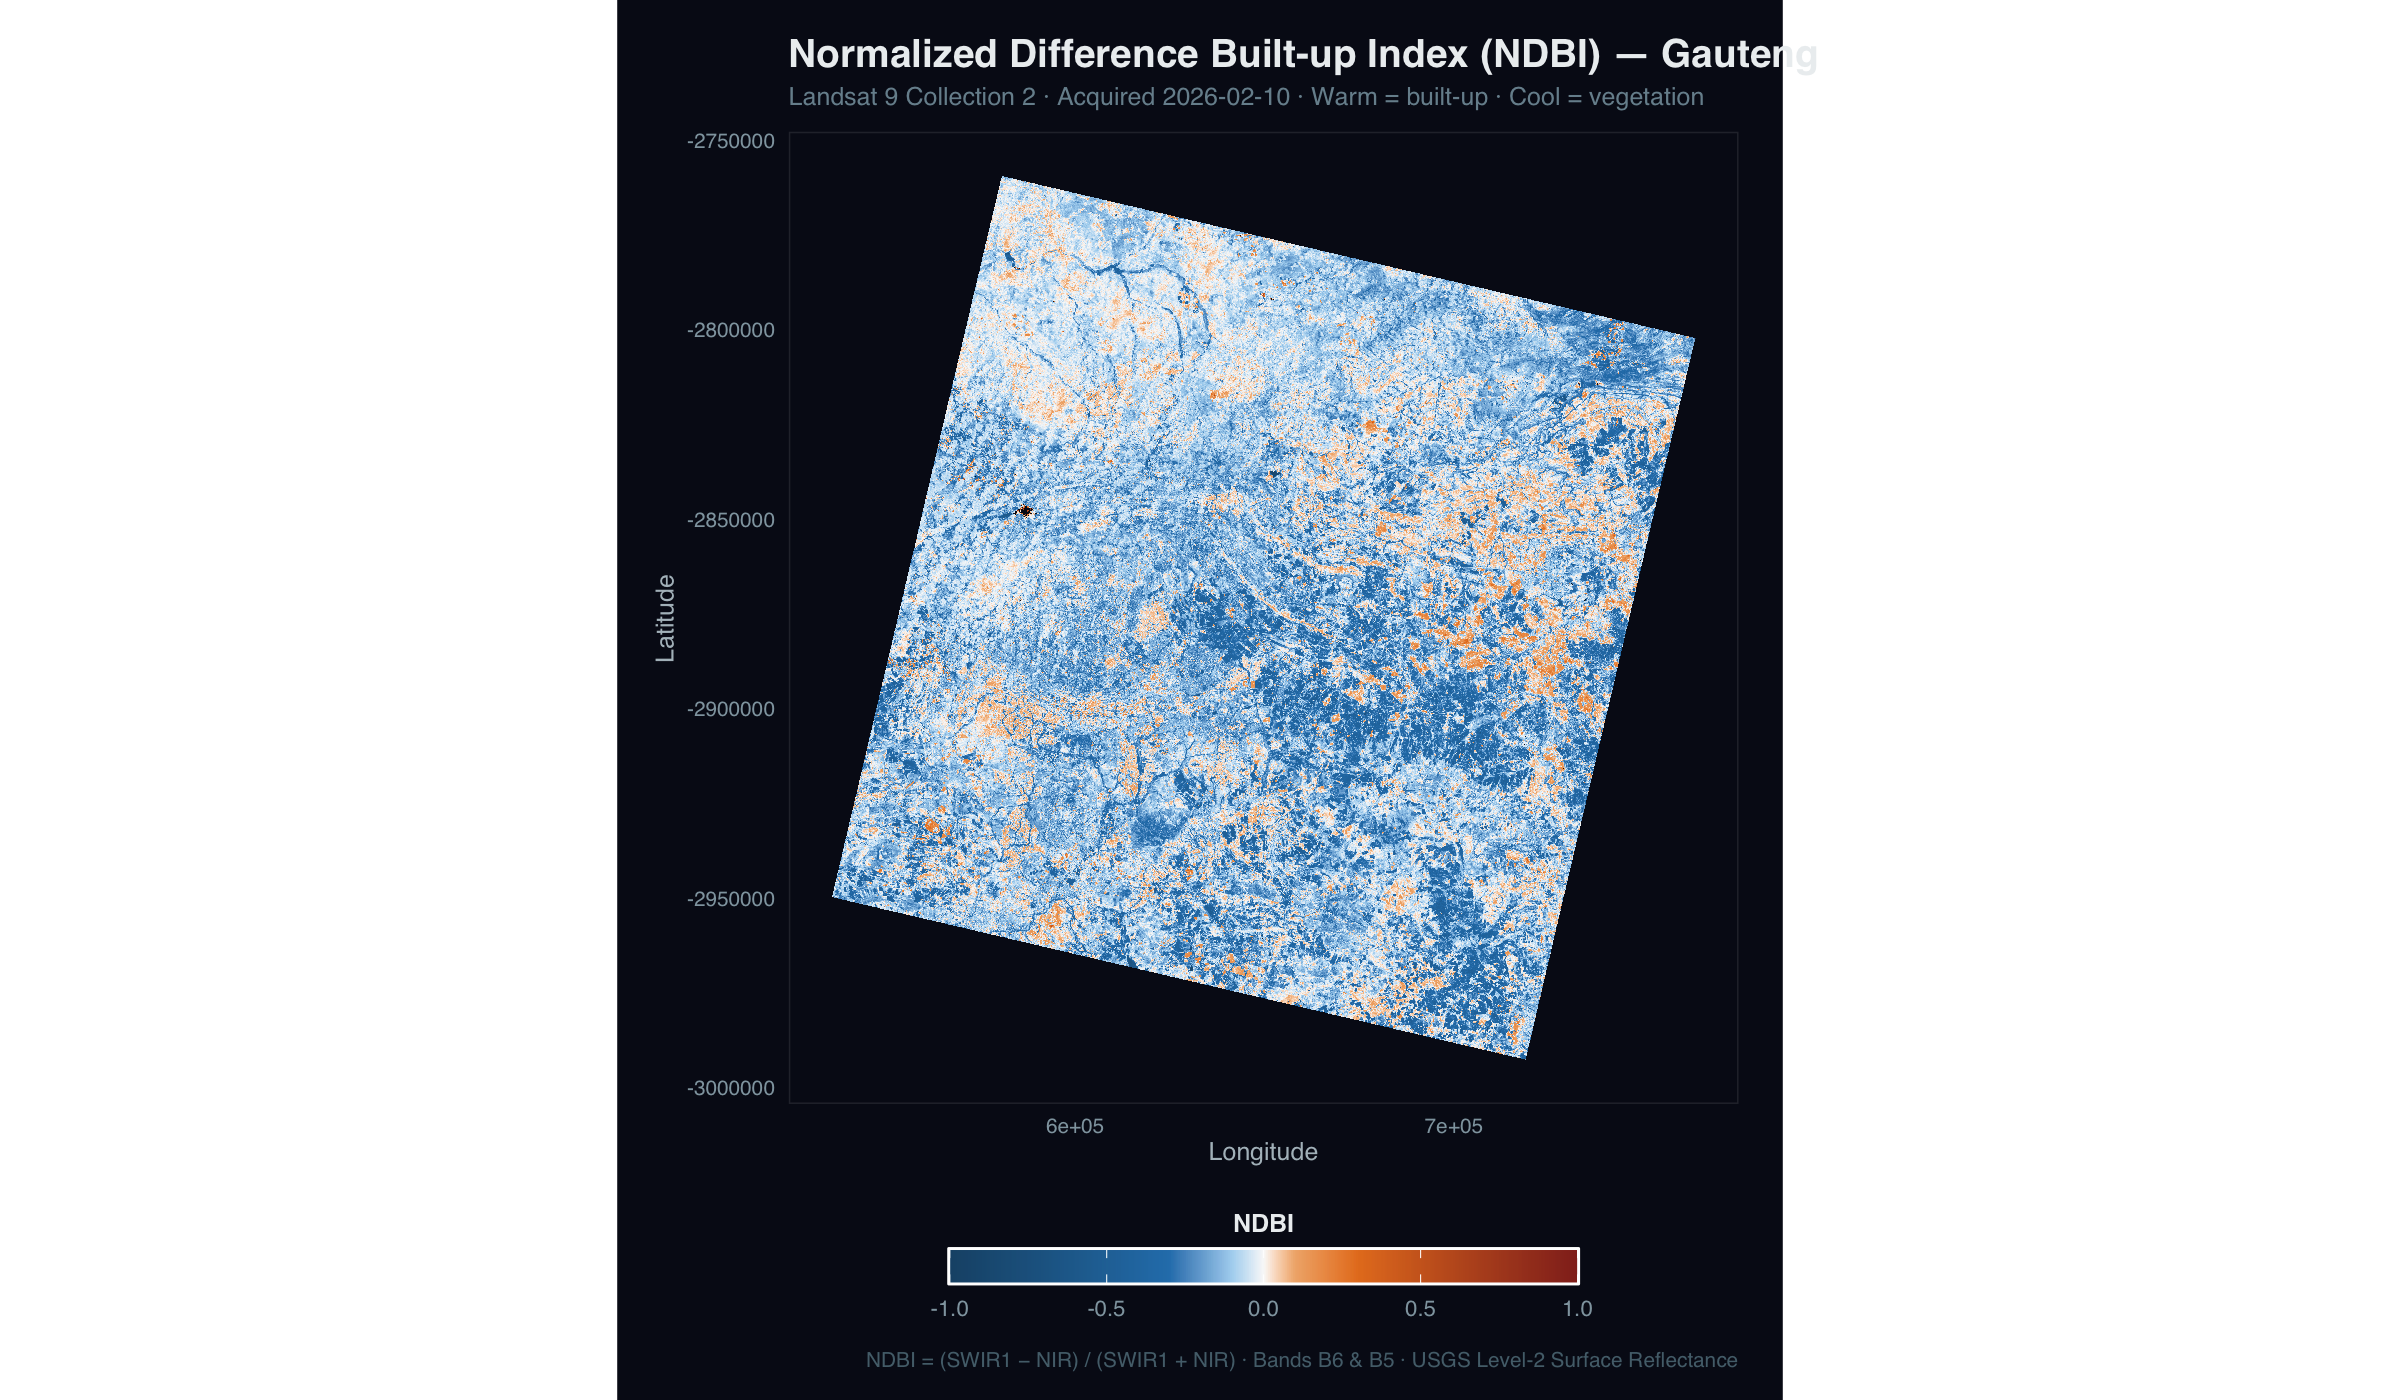

In [20]:
print(NdbiContinuousPlot)

The map is looking good, I have no complaints except for the Latitude and Longitude. I will not change them tough because it is not like I will publish the map. If you are following this to make publishable maps, you can look up online how to change them or you can ask me via any of my contact details or create an issue on GitHub and I will respond as soon as I can.

### Plot classified NDBI map

I was think of making the categorical version which is more immediately readable for communication purposes. We can make it so that we clearly see the urban footprint of Johannesburg and Pretoria as the orange/red zones.

In [21]:
CategoryColours <- c(
  "High Built-up"            = "#922b21",
  "Built-up"                 = "#e67e22",
  "Bare Soil / Mixed"        = "#f9e79f",
  "Sparse Vegetation"        = "#aed6a1",
  "Dense Vegetation / Water" = "#1a5276"
)

In [22]:
NdbiClassifiedPlot <- NDBI_Df %>%
  ggplot(aes(x = x, y = y, fill = category)) +
  geom_raster() +
  scale_fill_manual(
    values = CategoryColours,
    name   = "Land Surface Class",
    guide  = guide_legend(
      title.position = "top",
      title.hjust    = 0.5,
      nrow           = 2
    )
  ) +
  coord_equal() +
  labs(
    title    = "NDBI Land Surface Classification — Gauteng",
    subtitle = "Landsat 9 Collection 2 · Acquired 2026-02-10",
    caption  = "NDBI = (SWIR1 − NIR) / (SWIR1 + NIR) · Bands B6 & B5 · USGS Level-2 Surface Reflectance",
    x        = "Longitude",
    y        = "Latitude"
  ) +
  theme_minimal(base_family = "sans") +
  theme(
    plot.background   = element_rect(fill = "#070b1a", colour = NA),
    panel.background  = element_rect(fill = "#070b1a", colour = NA),
    panel.grid        = element_blank(),
    panel.border      = element_rect(colour = "#ffffff18", fill = NA,
                                     linewidth = 0.5),
    plot.title        = element_text(colour = "#eceff1", face = "bold",
                                     size = 14, margin = margin(b = 4)),
    plot.subtitle     = element_text(colour = "#78909c", size = 9,
                                     margin = margin(b = 8)),
    plot.caption      = element_text(colour = "#546e7a", size = 7.5),
    axis.text         = element_text(colour = "#90a4ae", size = 7.5),
    axis.title        = element_text(colour = "#b0bec5", size = 9),
    legend.position   = "bottom",
    legend.background = element_rect(fill = "#070b1a", colour = NA),
    legend.title      = element_text(colour = "#eceff1", size = 9,
                                     face = "bold"),
    legend.text       = element_text(colour = "#b0bec5", size = 8.5),
    plot.margin       = margin(14, 16, 12, 14)
  )

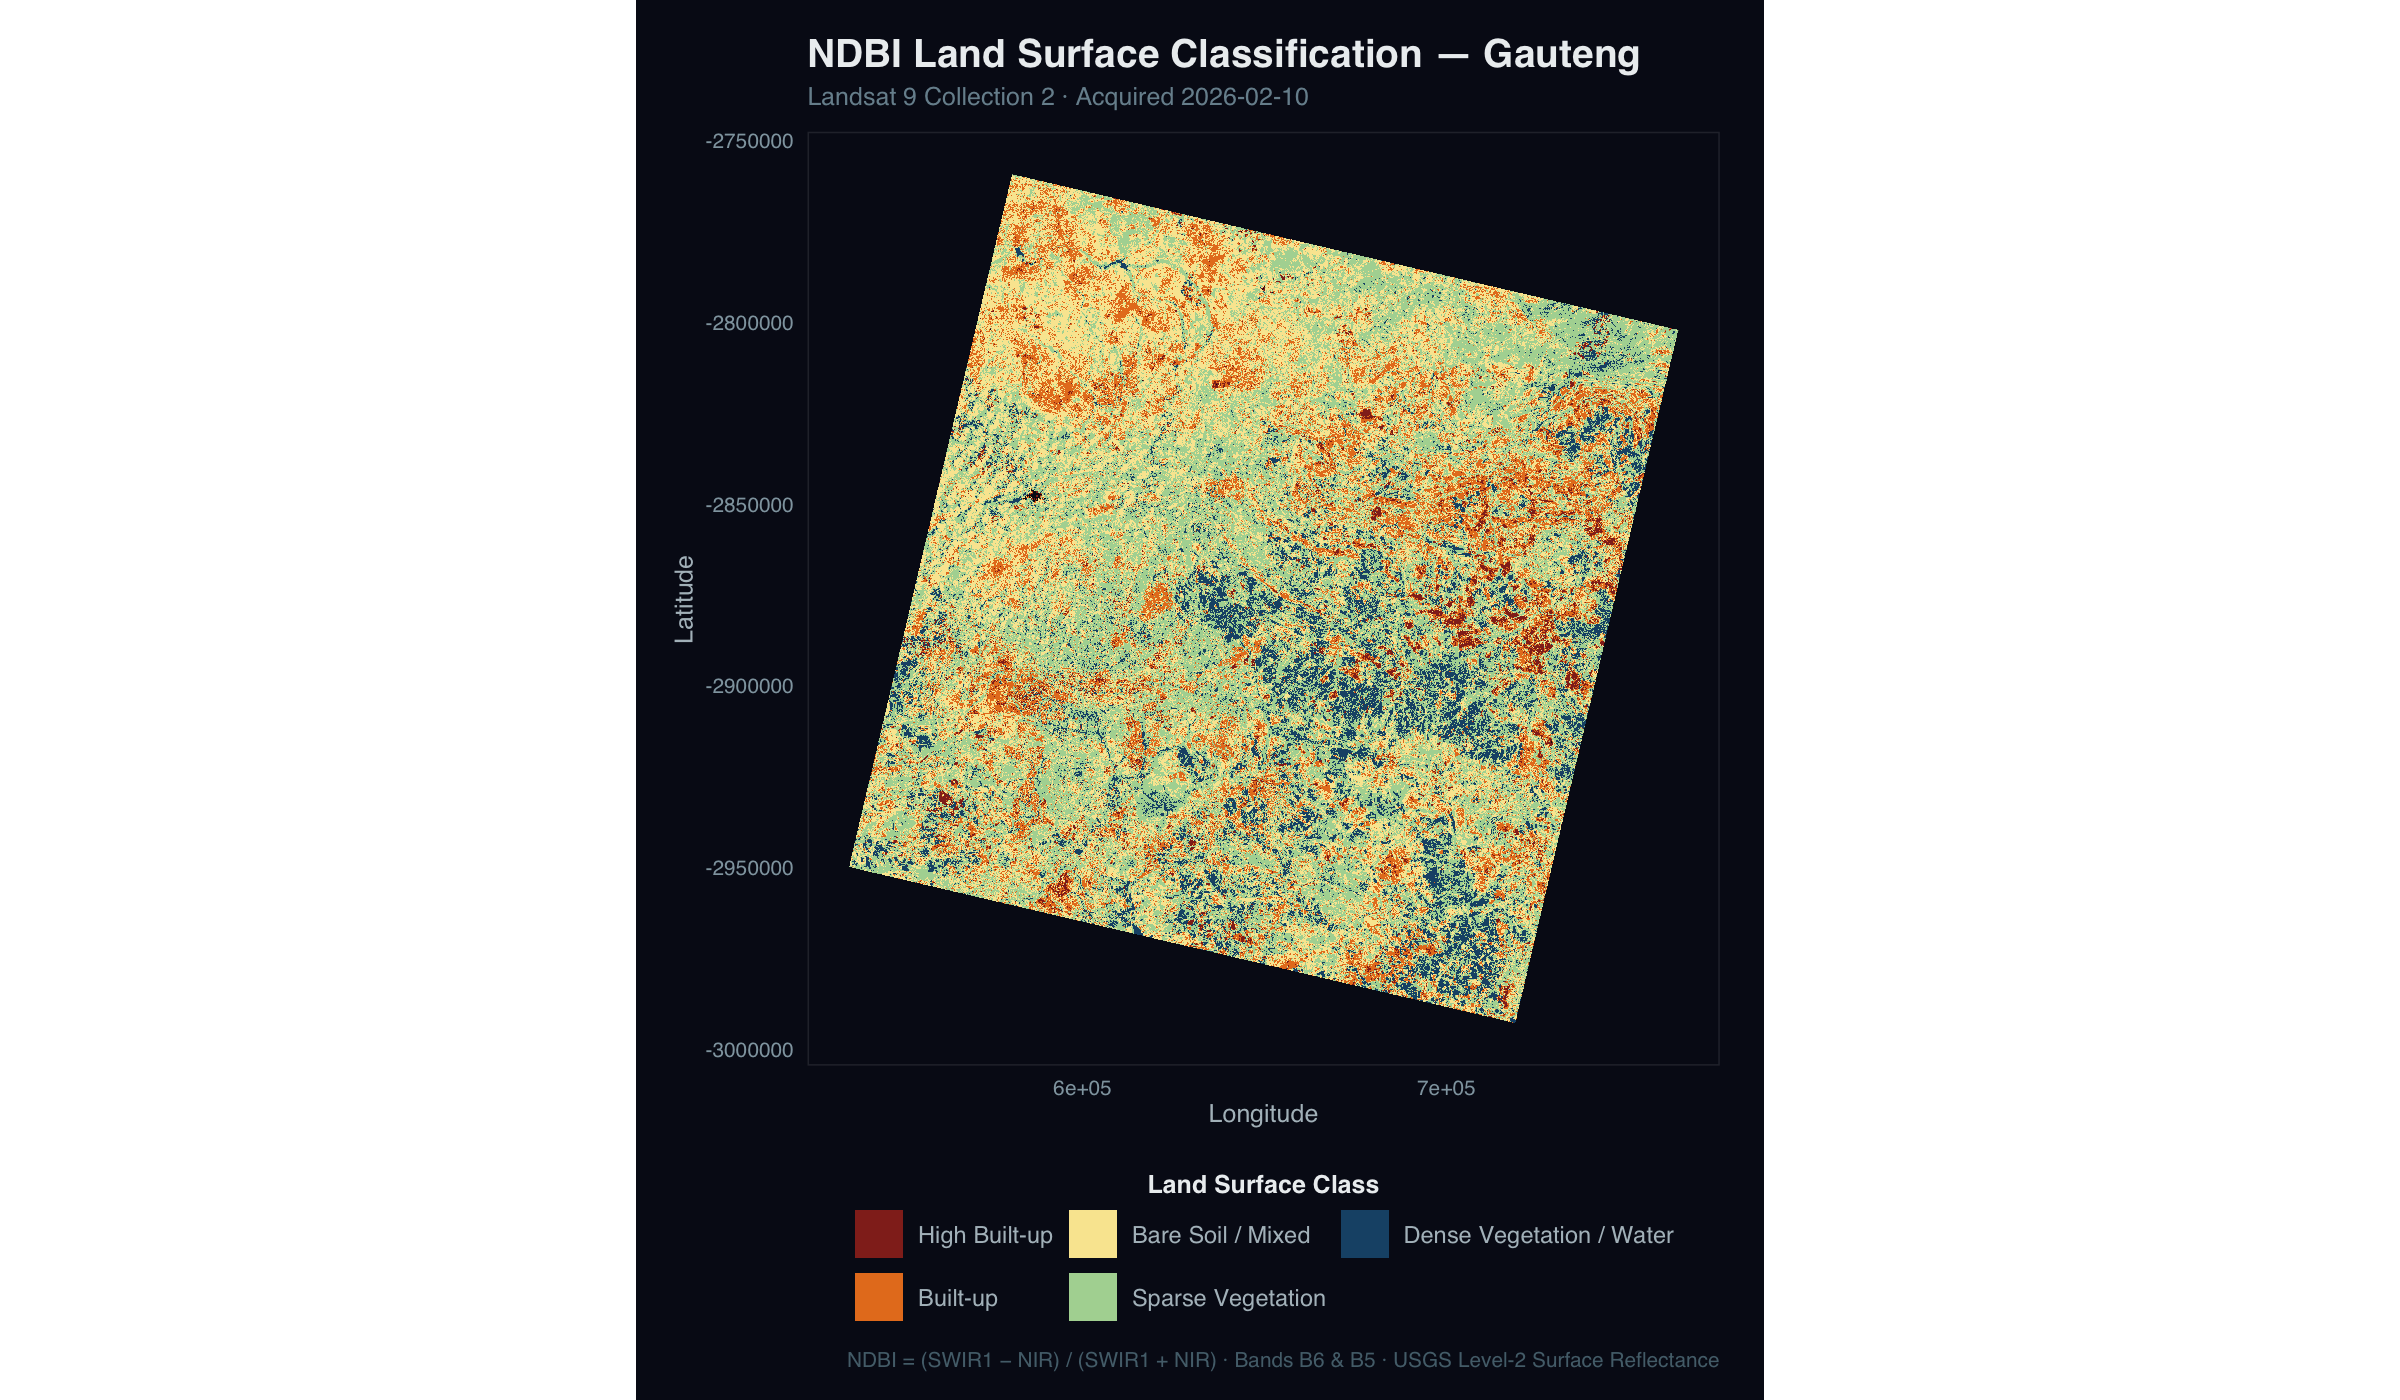

In [23]:
print(NdbiClassifiedPlot)

### Quick statistics per category

It is alwyas useful to report what percentage of the scene each category makes up.

In [24]:
AreaSummary <- NDBI_Df %>%
  count(category) %>%
  mutate(
    pct      = round(n / sum(n) * 100, 1),
    area_km2 = round(n * (30 * 2)^2 / 1e6, 1)   # 30m * aggregate factor 2
  )

In [25]:
print(AreaSummary)

# A tibble: 5 × 4
  category                       n   pct area_km2
  <fct>                      <int> <dbl>    <dbl>
1 High Built-up             270755   2.7     975.
2 Built-up                 1569949  15.4    5652.
3 Bare Soil / Mixed        3491691  34.2   12570.
4 Sparse Vegetation        3856945  37.8   13885 
5 Dense Vegetation / Water 1024126  10      3687.


That brings us to this section's conclusion. The maps can be further enhanced by adding the province boundaries and maybe point features for the aforementioned cities but that is work for another day.